# supply chain decision support system

**Tools:** python,SQL,pandas,Numpy,matplotlib,scipy,sklearn

**Goal:** Analyze and optimize supply chain using operations Research and machine learning

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
print("All libraries imported !")

All libraries imported !


In [2]:
# DataBase connection
conn=sqlite3.Connection("E:/pythonn/supply_chain_project/supply_chain.db")
cursor =conn.cursor()

#creare tables

cursor.executescript("""
    CREATE TABLE IF NOT EXISTS factories(
        id         INTEGER PRIMARY KEY,
        name       TEXT,
        capacity   INTEGER,
        location   TEXT
    );
    CREATE TABLE IF NOT EXISTS stores(
        id         INTEGER PRIMARY KEY,
        name       TEXT,
        demand     INTEGER,
        location   TEXT
    );
    CREATE TABLE IF NOT EXISTS transport_cost(
        factory_id   INTEGER,
        store_id     INTEGER,
        cost         REAL
    );
     CREATE TABLE IF NOT EXISTS sales_history (
        id       INTEGER PRIMARY KEY,
        store_id INTEGER,
        month    INTEGER,
        sales    INTEGER
    );
""")

conn.commit()
print("Database created !")

Database created !


In [3]:
# Insert data
 # Insert data
cursor.executescript("""
    INSERT OR IGNORE INTO factories VALUES
        (1, 'Factory_North', 100, 'North'),
        (2, 'Factory_South', 80,  'South'),
        (3, 'Factory_East',  120, 'East');
    
    INSERT OR IGNORE INTO stores VALUES
        (1, 'Store_A', 60, 'City_A'),
        (2, 'Store_B', 50, 'City_B'),
        (3, 'Store_C', 70, 'City_C'),
        (4, 'Store_D', 40, 'City_D');
    
    INSERT OR IGNORE INTO transport_cost VALUES
        (1,1,2), (1,2,3), (1,3,1), (1,4,4),
        (2,1,5), (2,2,4), (2,3,8), (2,4,2),
        (3,1,3), (3,2,6), (3,3,2), (3,4,7);
    
    INSERT OR IGNORE INTO sales_history VALUES
        (1,1,1,55), (2,1,2,60), (3,1,3,58), (4,1,4,65),
        (5,1,5,70), (6,1,6,68), (7,1,7,75), (8,1,8,72),
        (9,2,1,45), (10,2,2,48),(11,2,3,50),(12,2,4,52),
        (13,2,5,55),(14,2,6,58),(15,2,7,60),(16,2,8,63),
        (17,3,1,65),(18,3,2,68),(19,3,3,70),(20,3,4,72),
        (21,3,5,75),(22,3,6,78),(23,3,7,80),(24,3,8,82),
        (25,4,1,35),(26,4,2,38),(27,4,3,40),(28,4,4,42),
        (29,4,5,45),(30,4,6,48),(31,4,7,50),(32,4,8,52);
""")

conn.commit()
print(" Data inserted!")

 Data inserted!


In [4]:
# Display all data

df_factories = pd.read_sql("SELECT * FROM factories",conn)
df_stores =    pd.read_sql("SELECT * FROM stores",conn)
df_costs =    pd.read_sql("SELECT * FROM transport_cost",conn)

print("               Factories :      ")
print(df_factories)

print("\n              stores           ")
print(df_stores)

print("\n       Transportation costs    ")
print(df_costs.pivot(index="factory_id", columns="store_id", values="cost"))


               Factories :      
   id           name  capacity location
0   1  Factory_North       100    North
1   2  Factory_South        80    South
2   3   Factory_East       120     East

              stores           
   id     name  demand location
0   1  Store_A      60   City_A
1   2  Store_B      50   City_B
2   3  Store_C      70   City_C
3   4  Store_D      40   City_D

       Transportation costs    
store_id      1    2    3    4
factory_id                    
1           2.0  3.0  1.0  4.0
2           5.0  4.0  8.0  2.0
3           3.0  6.0  2.0  7.0


In [5]:
# Transportation Problem - Minimize cost
supply = df_factories["capacity"].tolist()  # [100, 80, 120]
demand = df_stores["demand"].tolist()        # [60, 50, 70, 40]
costs  = df_costs.pivot(index="factory_id", 
                        columns="store_id", 
                        values="cost").values.flatten()

# Build constraints
c = costs  # minimize total cost

# Supply constraints
A_supply = []
for i in range(3):
    row = [0] * 12
    for j in range(4):
        row[i*4 + j] = 1
    A_supply.append(row)

# Demand constraints
A_demand = []
for j in range(4):
    row = [0] * 12
    for i in range(3):
        row[i*4 + j] = -1
    A_demand.append(row)

A = A_supply + A_demand
b = supply + [-d for d in demand]

result = linprog(c, A_ub=A, b_ub=b, bounds=[(0,None)]*12)

print(f" Min Transport Cost: {round(result.fun, 2)}")

# Display results
x = result.x.reshape(3, 4).round(1)
df_result = pd.DataFrame(x,
    index=["Factory_N","Factory_S","Factory_E"],
    columns=["Store_A","Store_B","Store_C","Store_D"])
print("\n=== Optimal Distribution ===")
print(df_result)

 Min Transport Cost: 500.0

=== Optimal Distribution ===
           Store_A  Store_B  Store_C  Store_D
Factory_N     50.0     50.0      0.0      0.0
Factory_S      0.0      0.0      0.0     40.0
Factory_E     10.0      0.0     70.0      0.0


In [8]:
# Demand Forecasting with Linear Regression
df_sales = pd.read_sql("SELECT * FROM sales_history", conn)

# Train model for each store
print("=== Demand Forecast (Month 9) ===")
forecasts = {}

for store_id in range(1, 5):
    df_store = df_sales[df_sales["store_id"] == store_id]
    X = df_store[["month"]]
    y = df_store["sales"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    forecast = model.predict(pd.DataFrame([[9]], columns=["month"]))[0]
    forecasts[store_id] = round(forecast, 1)
    r2 = r2_score(y, model.predict(X))
    print(f"Store_{store_id}: forecast={round(forecast,1)} units (R²={round(r2,2)})")

=== Demand Forecast (Month 9) ===
Store_1: forecast=77.6 units (R²=0.88)
Store_2: forecast=65.3 units (R²=1.0)
Store_3: forecast=84.8 units (R²=1.0)
Store_4: forecast=54.8 units (R²=1.0)


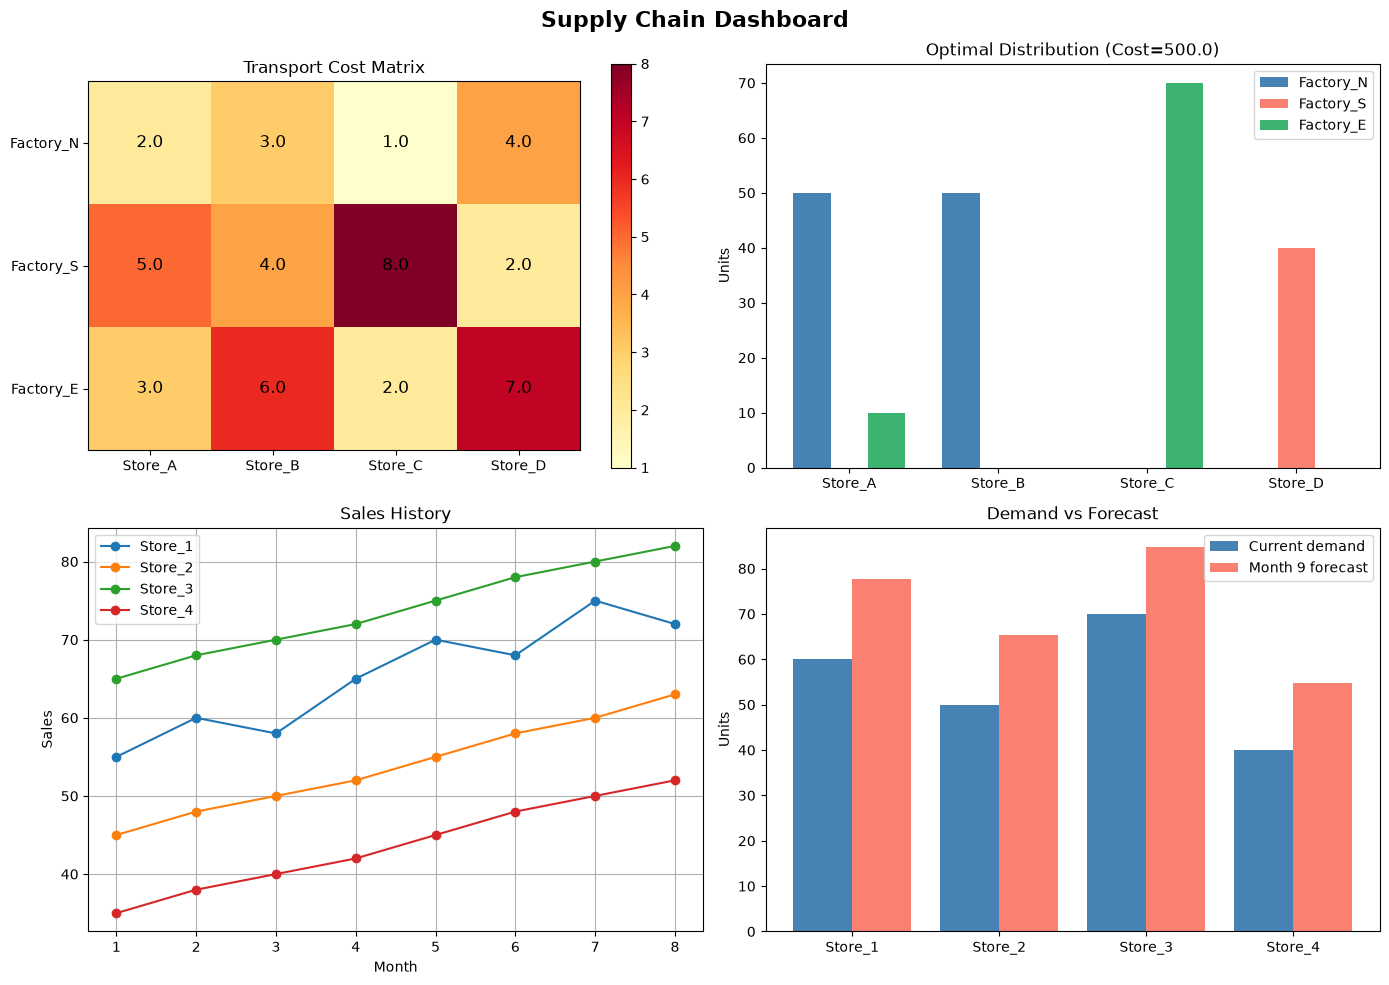

In [9]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Supply Chain Dashboard", fontsize=16, fontweight="bold")

# --- 1) Transport cost heatmap ---
ax1 = axes[0, 0]
cost_matrix = df_costs.pivot(index="factory_id", 
                              columns="store_id", 
                              values="cost").values
im = ax1.imshow(cost_matrix, cmap="YlOrRd")
ax1.set_xticks(range(4))
ax1.set_yticks(range(3))
ax1.set_xticklabels(["Store_A","Store_B","Store_C","Store_D"])
ax1.set_yticklabels(["Factory_N","Factory_S","Factory_E"])
ax1.set_title("Transport Cost Matrix")
for i in range(3):
    for j in range(4):
        ax1.text(j, i, cost_matrix[i,j], ha="center", va="center", fontsize=12)
plt.colorbar(im, ax=ax1)

# --- 2) Optimal distribution ---
ax2 = axes[0, 1]
x = np.arange(4)
width = 0.25
ax2.bar(x - width, df_result.iloc[0], width, label="Factory_N", color="steelblue")
ax2.bar(x,         df_result.iloc[1], width, label="Factory_S", color="salmon")
ax2.bar(x + width, df_result.iloc[2], width, label="Factory_E", color="mediumseagreen")
ax2.set_xticks(x)
ax2.set_xticklabels(["Store_A","Store_B","Store_C","Store_D"])
ax2.set_title(f"Optimal Distribution (Cost={result.fun})")
ax2.set_ylabel("Units")
ax2.legend()

# --- 3) Sales history ---
ax3 = axes[1, 0]
for store_id in range(1, 5):
    df_store = df_sales[df_sales["store_id"] == store_id]
    ax3.plot(df_store["month"], df_store["sales"], 
             marker="o", label=f"Store_{store_id}")
ax3.set_title("Sales History")
ax3.set_xlabel("Month")
ax3.set_ylabel("Sales")
ax3.legend()
ax3.grid(True)

# --- 4) Demand forecast ---
ax4 = axes[1, 1]
stores = [f"Store_{i}" for i in range(1, 5)]
forecast_values = list(forecasts.values())
current_demand  = df_stores["demand"].tolist()
x = np.arange(4)
ax4.bar(x - 0.2, current_demand,  0.4, label="Current demand",  color="steelblue")
ax4.bar(x + 0.2, forecast_values, 0.4, label="Month 9 forecast", color="salmon")
ax4.set_xticks(x)
ax4.set_xticklabels(stores)
ax4.set_title("Demand vs Forecast")
ax4.set_ylabel("Units")
ax4.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Final Summary
print("=" * 50)
print("   SUPPLY CHAIN DECISION SUPPORT SYSTEM")
print("=" * 50)

print(f"\n📦 Factories: {len(df_factories)}")
print(f"  🏪 Stores: {len(df_stores)}")
print(f"\n🚚 Optimal Transport Cost: {round(result.fun, 2)} DZD")
print(f"\n📈 Demand Forecast (Month 9):")
for store_id, forecast in forecasts.items():
    print(f"   Store_{store_id}: {forecast} units")

print(f"\n✅ System ready for decision making!")
print("=" * 50)

# Close connection
conn.close()
print("\n🔒 Database closed!")

   SUPPLY CHAIN DECISION SUPPORT SYSTEM

📦 Factories: 3
🏪 Stores: 4

🚚 Optimal Transport Cost: 500.0 DZD

📈 Demand Forecast (Month 9):
   Store_1: 77.6 units
   Store_2: 65.3 units
   Store_3: 84.8 units
   Store_4: 54.8 units

✅ System ready for decision making!

🔒 Database closed!
